# Visualizing results.json Data

This notebook reads and visualizes the evaluation results stored in `results/results.json`, comparing the baseline approach with the tokensaver approach across various metrics.


## 1. Import Required Libraries

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Load JSON Data
Read the data from `results/results.json`.

In [2]:
with open('results/results.json') as f:
    raw_data = json.load(f)

tasks = {k: v for k, v in raw_data.items() if not k.startswith('_')}
print(f"Loaded {len(tasks)} tasks.")

Loaded 30 tasks.


## 3. Preprocess Data into DataFrame

In [3]:
TOKEN_COLS = ['input_tokens', 'cache_creation_input_tokens', 'cache_read_input_tokens',
              'output_tokens', 'total_tokens', 'n_turns', 'intent_score']

def parse_checklist(value):
    if not value:
        return None, None, None
    passed, total = map(int, value.split('/'))
    return passed, total, (passed / total * 100 if total > 0 else None)

records = []
for task_id, conditions in tasks.items():
    for condition, metrics in conditions.items():
        ch_passed, ch_total, ch_pct = parse_checklist(metrics.get('checklist'))
        records.append({
            'task_id': task_id,
            'condition': condition,
            **{col: metrics.get(col, 0) for col in TOKEN_COLS},
            'checklist_passed': ch_passed,
            'checklist_total': ch_total,
            'checklist_pct': ch_pct,
        })

df = pd.DataFrame(records)
df.head()

,task_id,condition,input_tokens,cache_creation_input_tokens,cache_read_input_tokens,output_tokens,total_tokens,n_turns,intent_score,checklist_passed,checklist_total,checklist_pct
0,08ec77ee77934f20,baseline,4,12572,23326,1718,14294,2,4,10,10,100.000000
1,08ec77ee77934f20,tokensaver,4,12612,23326,1248,13864,2,4,10,10,100.000000
2,10e4408e92944017,baseline,11,21369,130565,7288,28668,8,4,7,12,58.333333
3,10e4408e92944017,tokensaver,11,20886,130221,6755,27652,8,4,12,12,100.000000
4,19a3d90b4b2441d7,baseline,15,33612,199004,22732,56359,12,4,11,16,68.750000


## 4. Tradeoff Analysis: Token Savings vs Quality

In [ ]:
df_pivot = df.pivot(index='task_id', columns='condition')
df_pivot.columns = [f"{cond}_{metric}" for metric, cond in df_pivot.columns]
df_pivot = df_pivot.reset_index().dropna(subset=['baseline_output_tokens', 'tokensaver_output_tokens'])

df_pivot['output_savings_abs'] = df_pivot['baseline_output_tokens'] - df_pivot['tokensaver_output_tokens']
df_pivot['output_savings_pct'] = df_pivot['output_savings_abs'] / df_pivot['baseline_output_tokens'] * 100
df_pivot['checklist_delta'] = df_pivot['tokensaver_checklist_pct'] - df_pivot['baseline_checklist_pct']

avg_b = df_pivot['baseline_output_tokens'].mean()
avg_t = df_pivot['tokensaver_output_tokens'].mean()

cl = df_pivot.dropna(subset=['baseline_checklist_pct', 'tokensaver_checklist_pct'])
it = df_pivot.dropna(subset=['baseline_intent_score', 'tokensaver_intent_score'])

b_pass_total = cl['baseline_checklist_passed'].sum()
t_pass_total = cl['tokensaver_checklist_passed'].sum()

ch_total_items = cl['baseline_checklist_total'].sum()

b_micro_pct = (b_pass_total / ch_total_items * 100) if ch_total_items else 0
t_micro_pct = (t_pass_total / ch_total_items * 100) if ch_total_items else 0

summary = pd.DataFrame([
    {
        'Metric':     'Output tokens (avg)',
        'Baseline':   f"{avg_b:,.0f}",
        'Tokensaver': f"{avg_t:,.0f}",
        'Change':     f"{(avg_t - avg_b) / avg_b * 100:+.1f}%",
    },
    {
        'Metric':     'Total tokens (avg)',
        'Baseline':   f"{df_pivot['baseline_total_tokens'].mean():,.0f}",
        'Tokensaver': f"{df_pivot['tokensaver_total_tokens'].mean():,.0f}",
        'Change':     f"{(df_pivot['tokensaver_total_tokens'].mean() - df_pivot['baseline_total_tokens'].mean()) / df_pivot['baseline_total_tokens'].mean() * 100:+.1f}%",
    },
    {
        'Metric':     'Checklist pass rate (micro avg)',
        'Baseline':   f"{b_micro_pct:.0f}%",
        'Tokensaver': f"{t_micro_pct:.0f}%",
        'Change':     f"{t_micro_pct - b_micro_pct:+.0f}pp",
    },
    {
        'Metric':     'Intent score (avg)',
        'Baseline':   f"{it['baseline_intent_score'].mean():.1f}/5",
        'Tokensaver': f"{it['tokensaver_intent_score'].mean():.1f}/5",
        'Change':     f"{it['tokensaver_intent_score'].mean() - it['baseline_intent_score'].mean():+.1f}",
    },
]).set_index('Metric')

summary

,Baseline,Tokensaver,Change
Metric,,,
Output tokens (avg),"8,015","5,923",-26.1%
Total tokens (avg),"20,135","18,017",-10.5%
Checklist pass rate (micro avg),78%,73%,-5pp
Intent score (avg),4.1/5,4.1/5,-0.1


/var/folders/69/yq0yl5cs3zv0ftzrc82fryyc0000gn/T/ipykernel_132/3872941208.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='condition', y='output_tokens', ax=ax, errorbar='ci', capsize=.1, palette='Set2')


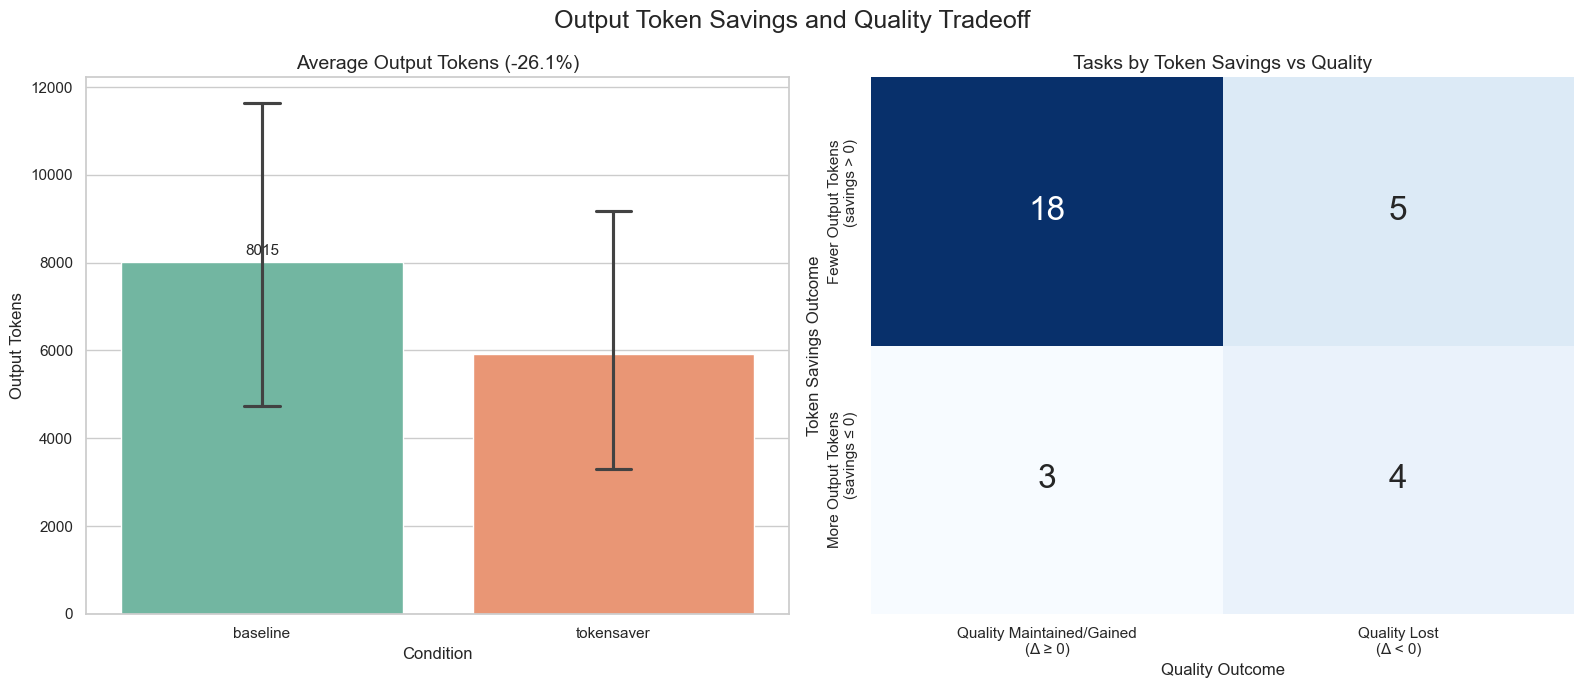

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Output Token Savings and Quality Tradeoff', fontsize=18)

# Average output tokens per condition
ax = axes[0]
sns.barplot(data=df, x='condition', y='output_tokens', ax=ax, errorbar='ci', capsize=.1, palette='Set2')
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3, size=11)
ax.set_title(f'Average Output Tokens ({(avg_t - avg_b) / avg_b * 100:+.1f}%)', fontsize=14)
ax.set(xlabel='Condition', ylabel='Output Tokens')

# 2x2 quadrant: token savings vs quality
ax = axes[1]
saved = df_pivot['output_savings_abs'] > 0
improved = df_pivot['checklist_delta'] >= 0
quadrant = np.array([
    [len(df_pivot[ saved &  improved]), len(df_pivot[ saved & ~improved])],
    [len(df_pivot[~saved &  improved]), len(df_pivot[~saved & ~improved])],
])
sns.heatmap(quadrant, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['Quality Maintained/Gained\n(Δ ≥ 0)', 'Quality Lost\n(Δ < 0)'],
            yticklabels=['Fewer Output Tokens\n(savings > 0)', 'More Output Tokens\n(savings ≤ 0)'],
            annot_kws={'size': 24})
ax.set_title('Tasks by Token Savings vs Quality', fontsize=14)
ax.set(xlabel='Quality Outcome', ylabel='Token Savings Outcome')

plt.tight_layout()
plt.show()